In [234]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract Input and Output Columns
# 2. Scale the Values
# 3. Train Test Split
# 4. Train the Model
# 5. Evaluate the Model / Model Selection
# 6. Deploy the Model

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [236]:
df = pd.read_csv('placement.csv')

In [237]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [238]:
df.shape

(100, 4)

In [239]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [240]:
# preprocess

df.iloc[:,1:]

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


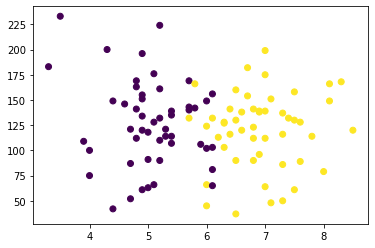

In [241]:
# EDA

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [242]:
# Extract Input and Output Columns

x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [243]:
x

,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [244]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [245]:
# Train Test Split

from sklearn.model_selection import train_test_split

In [246]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1)

In [247]:
x_train

,Unnamed: 0,cgpa
2,2,5.3
78,78,6.1
69,69,8.5
57,57,6.5
4,4,5.8
...,...,...
0,0,6.8
99,99,6.2
97,97,6.7
92,92,5.2


In [248]:
y_train

2     0
78    0
69    1
57    1
4     0
     ..
0     1
99    1
97    1
92    0
90    1
Name: placement, Length: 90, dtype: int64

In [249]:
# Scale the Values

from sklearn.preprocessing import StandardScaler

In [250]:
scaler = StandardScaler()

In [251]:
x_train = scaler.fit_transform(x_train)

In [252]:
x_train

array([[-1.68399267, -0.7049374 ],
       [ 0.94160794,  0.02535746],
       [ 0.63068155,  2.21624206],
       [ 0.21611303,  0.39050489],
       [-1.61489791, -0.24850311],
       [-0.23300286,  1.30337347],
       [ 0.45794467,  0.84693918],
       [-0.54392925,  0.66436547],
       [-0.30209761,  1.39466033],
       [-0.37119237, -1.07008484],
       [-0.64757138,  0.84693918],
       [ 1.25253432, -0.33978997],
       [-1.51125579, -0.97879798],
       [ 0.83796581, -1.1613717 ],
       [-0.71666613,  1.39466033],
       [ 1.56346071, -1.52651913],
       [-0.92395039, -1.25265855],
       [ 0.35430254,  1.12079976],
       [-1.06213989,  0.48179175],
       [ 0.28520778, -1.1613717 ],
       [-0.68211875, -1.98295342],
       [ 0.52703942,  0.75565233],
       [ 1.04525006, -0.61365055],
       [-0.75121351,  0.84693918],
       [ 0.87251318, -1.07008484],
       [ 1.18343957, -0.24850311],
       [ 1.14889219, -0.33978997],
       [-1.26942415,  0.02535746],
       [-0.95849776,

In [253]:
x_test = scaler.transform(x_test)

In [254]:
x_test

array([[-1.58035054,  0.93822604],
       [-0.0257186 , -2.34810085],
       [ 1.32162908, -1.07008484],
       [-1.3385189 , -0.61365055],
       [-0.06026598, -0.61365055],
       [-0.99304514, -1.07008484],
       [ 0.73432368,  1.12079976],
       [-1.16578202, -2.53067457],
       [-0.57847662, -1.1613717 ],
       [-0.613024  , -0.0659294 ]])

In [255]:
# Train the Model

from sklearn.linear_model import LogisticRegression

In [256]:
clf = LogisticRegression()

In [257]:
clf.fit(x_train, y_train)

LogisticRegression()

In [258]:
# Evaluate the Model / Model Selection

y_pred = clf.predict(x_test)

In [259]:
y_pred

array([1, 0, 0, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [260]:
y_test

5     1
50    0
89    0
12    0
49    0
22    0
72    1
17    0
34    0
33    0
Name: placement, dtype: int64

In [261]:
from sklearn.metrics import accuracy_score

In [262]:
accuracy_score(y_test, y_pred)

1.0

In [263]:
from mlxtend.plotting import plot_decision_regions

<AxesSubplot:>

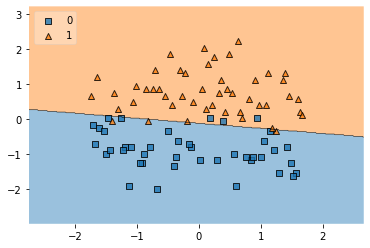

In [266]:
plot_decision_regions(x_train, y_train.values,
                                clf=clf, legend=2)

In [265]:
fig

<AxesSubplot:>

In [268]:
import pickle

In [269]:
pickle.dump(clf, open('model.pkl','wb'))